# Lecture 3: Building makemore Part 2 — MLP 字符级语言模型

本 notebook 跟随 Andrej Karpathy 的 [Neural Networks: Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ) 系列课程第 3 讲，
实现 Bengio et al. (2003) 提出的多层感知机（MLP）字符级语言模型。
与 Lecture 2 的 bigram 模型（只看前 1 个字符）不同，MLP 使用一个**上下文窗口（context window）**，
同时看前 N 个字符来预测下一个字符，大幅提升了生成质量。

**学习路线：**
1. 数据准备与字符编码 — 构建 `stoi` / `itos` 映射，制作滑动窗口训练样本
2. MLP 前向传播 — 嵌入层（Embedding）、隐藏层（Hidden Layer + tanh）、输出层（Logits）
3. 损失函数与交叉熵 — 手动实现 vs `F.cross_entropy`
4. 反向传播与梯度下降 — 手动训练循环，mini-batch SGD
5. 超参数调优 — 学习率扫描（Learning Rate Sweep）、网络规模实验
6. 训练集 / 验证集 / 测试集划分 — 检测过拟合
7. 采样生成 — 用训练好的模型生成新名字
8. 可视化与调试 — 嵌入空间可视化、损失曲线、`view` / `storage` 底层原理

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# ============================================================
# 读取数据集：32033 个英文名字，每行一个
# ============================================================
words=open('D:\\Vault-4\\Projects\\makemore\\names.txt', 'r').read().splitlines()
words[:8]                                # 预览前 8 个名字

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

## 1. 数据加载与字符编码（Character Encoding）

**概念解释：** 神经网络只能处理数字，所以第一步是把字符映射成整数索引。
我们为 26 个英文字母分配索引 1-26，用特殊字符 `'.'`（索引 0）表示单词的起始和结束。

**直觉理解：** 这就像给每个字符发一张"身份证号"。有了映射表 `stoi`，
我们可以把任意字符串翻译成数字序列交给神经网络；反过来 `itos` 让我们把输出翻译回字符。

**生活类比：** 就像摩尔斯电码把字母转成点和横一样，`stoi` 把字母转成数字。
电报员看到点横能还原字母（`itos`），神经网络看到数字也能还原字符。

- 总共 27 个"类别"：26 个字母 + 1 个特殊符号 `.`
- `stoi` = string to index（字符 → 数字）
- `itos` = index to string（数字 → 字符）

In [3]:
len(words)                               # 数据集中总共有 32033 个名字

32033

In [4]:
# ============================================================
# 构建字符 <-> 索引的双向映射表
# 26 个字母 -> 索引 1~26，特殊符号 '.' -> 索引 0
# ============================================================
chars=sorted(list(set(''.join(words))))  # 提取所有出现过的字符并排序 -> ['a','b',...,'z']
stoi={s:i+1 for i,s in enumerate(chars)} # 字符->索引映射，a=1, b=2, ..., z=26
stoi['.']=0                              # 特殊符号 '.' 用作起始/终止标记，索引为 0
itos={i:s for s,i in stoi.items()}       # 索引->字符映射（反向查找表）

## 2. 构建训练数据集 — 滑动窗口（Sliding Window）

**概念解释：** MLP 模型使用一个固定大小的**上下文窗口**（`block_size=3`）来预测下一个字符。
对于每个名字，我们用滑动窗口的方式提取所有"前 3 个字符 → 下一个字符"的训练样本。

**直觉理解：** 想象你在玩一个猜字游戏——你只能看到最近的 3 个字母，然后猜下一个。
比如看到 `e, m, m`，你猜下一个是 `a`（因为 "emma" 是常见名字）。
`block_size` 就是你的"记忆窗口"——看得越多，猜得越准，但模型也越复杂。

$$X_{\text{shape}} = (N, \text{block\_size}), \quad Y_{\text{shape}} = (N,)$$

逐项解读：
- $N$ = 所有名字产生的训练样本总数
- $X$ 的每一行 = 上下文窗口中 3 个字符的索引
- $Y$ 的每个元素 = 要预测的下一个字符的索引
- 整个过程：把"预测下一个字符"转化成"给定 3 个数字，预测第 4 个数字"的分类问题

**生活类比：** 就像手机输入法——你打了 3 个字母 `e, m, m`，手机给你推荐 `a`（因为 emma 是常见名字）。
训练数据就是所有这些"输入 → 推荐"的记录。

In [5]:
# ============================================================
# 构建训练数据集（仅用前 5 个名字演示，打印每个滑动窗口）
# 每个样本：context(3个字符索引) -> target(下一个字符索引)
# ============================================================
block_size=3                             # 上下文窗口大小：看前 3 个字符预测下一个
X, Y=[], []                              # X: 输入上下文列表，Y: 目标字符列表
for w in words[:5]:                      # 先用前 5 个名字演示
    print(w)
    context=[0]*block_size               # 初始上下文全为 0，即 '...'
    for ch in w+'.':                     # 遍历名字的每个字符（末尾加终止符 '.'）
        ix=stoi[ch]                      # 当前字符转索引
        X.append(context)                # 记录当前上下文作为输入
        Y.append(ix)                     # 记录当前字符作为目标
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context=context[1:]+[ix]         # 滑动窗口：丢掉最左边，加入当前字符

X=torch.tensor(X)                        # 转为 PyTorch 张量，shape=(32, 3)
Y=torch.tensor(Y)                        # 转为 PyTorch 张量，shape=(32,)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [6]:
X.shape, Y.shape                        # 输入输出的形状

(torch.Size([32, 3]), torch.Size([32]))

## 3. 嵌入层（Embedding Layer）— 从查表到学习

**概念解释：** 嵌入层的作用是把每个字符的整数索引映射成一个低维向量。
矩阵 $C$ 的形状是 $(27, 2)$，表示 27 个字符各有一个 2 维的"嵌入向量"。
通过 `C[X]`，PyTorch 自动把每个索引替换成对应的向量。

**直觉理解：** 为什么不直接用整数索引？因为整数之间有大小关系（$a=1 < z=26$），
但字母之间其实没有这种"大小"关系。嵌入向量让每个字符在一个**连续空间**中有自己的位置，
而且这个位置是**可学习的**——训练过程中，相似字符（如元音 a/e/i/o/u）会自动靠拢。

$$\text{emb} = C[X] \quad \Rightarrow \quad (N, 3) \xrightarrow{\text{查表}} (N, 3, 2)$$

逐项解读：
- $C$ = 嵌入矩阵，shape $(27, 2)$：27 个字符，每个用 2 维向量表示
- $X$ = 输入索引矩阵，shape $(N, 3)$：N 个样本，每个有 3 个字符索引
- $\text{emb}$ = 嵌入结果，shape $(N, 3, 2)$：每个索引被替换成 2 维向量

> **💡 深入理解：** `C[X]` 和 one-hot 编码 + 矩阵乘法是等价的
>
> `F.one_hot(tensor([5]), 27).float() @ C` 和 `C[5]` 结果完全一样！
> 但直接用索引查表比 one-hot 乘法快得多——one-hot 向量有 27 个元素，其中 26 个是 0，
> 做矩阵乘法时这些 0 全是浪费的计算。直接查表是 $O(1)$，乘法是 $O(27 \times d)$。

**生活类比：** 嵌入矩阵就像一本"字符画像手册"。
每个字符有一页，上面写着它的"特征坐标"（2 个数字）。
`C[5]` 就是翻到第 5 页直接看坐标，而 one-hot 乘法相当于把整本手册乘一遍才找到那一页——结果一样，但白费力气。

In [7]:
C=torch.randn((27,2))                   # 随机初始化嵌入矩阵：27个字符 x 2维嵌入向量

In [8]:
emb=C[X]                                # 用索引查表：(32,3) -> (32,3,2)，每个索引变成2维向量
emb.shape                               # 32个样本，每个有3个字符，每个字符用2维向量表示

torch.Size([32, 3, 2])

## 4. 隐藏层（Hidden Layer）— 网络的"思考"层

**概念解释：** 嵌入层给了我们每个字符的向量表示，但这些向量还是独立的。
隐藏层通过矩阵乘法 + 非线性激活函数（tanh），将 3 个字符的嵌入**混合**在一起，
提取它们的组合模式。

**直觉理解：** 隐藏层就像一个"模式识别器"。它不是单独看每个字符，
而是把 3 个字符的向量拼成一个长向量（`view(-1, 6)`），然后通过矩阵乘法寻找模式。
比如 `e, m, m` 这个组合出现时，隐藏层某些神经元会强烈激活，
因为它学到了"这个模式后面通常跟 `a`"。

$$h = \tanh(\text{emb.view}(-1, 6) \cdot W_1 + b_1)$$

逐项解读：
- `emb.view(-1, 6)`：把 $(N, 3, 2)$ 展平为 $(N, 6)$，拼接 3 个字符的嵌入
- $W_1$：权重矩阵 $(6, 100)$，将 6 维输入映射到 100 维隐藏空间
- $b_1$：偏置 $(100,)$，通过广播机制自动扩展
- $\tanh$：激活函数，将输出压缩到 $(-1, 1)$，引入非线性

**生活类比：** 如果嵌入层是"每个字符的身份证"，隐藏层就是"面试官"。
面试官不会单独看每一项资料，而是**综合考虑**所有资料（矩阵乘法 = 加权汇总），
然后给出 100 个维度的"评分"（tanh 保证评分在 -1 到 1 之间）。

In [9]:
W1=torch.randn((6,100))                 # 隐藏层权重：6维输入(3x2嵌入拼接) -> 100维隐藏层
b1=torch.randn(100)                     # 隐藏层偏置：100个神经元各有一个偏置

In [10]:
# ============================================================
# 隐藏层前向传播：拼接嵌入 -> 矩阵乘法 -> 加偏置 -> tanh激活
# emb: (32,3,2) -> view: (32,6) -> @W1+b1: (32,100) -> tanh: (32,100)
# ============================================================
h=torch.tanh(emb.view(-1, 6) @ W1 + b1) # 广播机制：b1 自动扩展匹配 batch 维度
h, h.shape                               # h: (32, 100)，每个样本得到 100 维隐藏表示

(tensor([[ 0.9344, -0.8410, -0.0634,  ..., -0.9671,  0.9946,  0.9957],
         [ 0.9260, -0.4920,  0.1657,  ..., -0.7596,  0.9983,  0.9649],
         [ 0.9974,  0.8588,  0.9225,  ..., -0.0796,  0.5254,  0.9721],
         ...,
         [ 0.9847, -0.7240,  1.0000,  ..., -0.9805, -1.0000, -0.8570],
         [-1.0000,  0.0497,  0.9999,  ..., -0.9990, -0.9999, -0.9751],
         [ 0.9914, -0.9845,  0.9871,  ..., -0.9799,  0.9703,  0.9201]]),
 torch.Size([32, 100]))

## 5. 输出层与损失函数 — 从隐藏表示到概率分布

**概念解释：** 输出层将 100 维的隐藏表示映射成 27 维的 logits（每个字符一个分数）。
然后通过 softmax 将 logits 转化为概率分布，最后用交叉熵（Cross-Entropy）计算损失。

**直觉理解：** logits 就像"原始考试分数"——可以是任意数字，有正有负。
但我们需要的是"每个字符被选中的概率"，概率必须满足：非负 + 和为 1。
Softmax 两步搞定：`exp()` 保证非负，除以总和保证归一化。

$$p_i = \text{softmax}(\text{logits})_{y_i} = \frac{e^{\text{logits}[i, y_i]}}{\sum_j e^{\text{logits}[i, j]}}$$

$$\text{loss} = -\frac{1}{N}\sum_{i=1}^{N} \log(p_i)$$

逐项解读：
- $p_i$：softmax 概率中，第 $i$ 个样本的正确类别 $y_i$ 对应的概率
- $\frac{e^{\text{logits}[i, y_i]}}{\sum_j e^{\text{logits}[i,j]}}$：就是 softmax 本身——分子是正确类别的 exp，分母是所有类别的 exp 之和（归一化因子）
- $-\log(p_i)$：概率越高 loss 越低；概率 = 1 时 loss = 0
- 整个公式：计算"模型有多确信正确答案"，越确信 loss 越低

**生活类比：** 想象 27 个学生举手表示"我是正确答案"，举手高度就是 logits。
Softmax 把高度转成概率（举得越高占比越大）。Loss 衡量：正确答案那个学生举手够不够高？

In [11]:
W2=torch.randn((100,27))                # 输出层权重：100维隐藏 -> 27维logits（每个字符一个分数）
b2=torch.randn(27)                      # 输出层偏置：27个字符各一个

In [12]:
logits=h @ W2 + b2                      # 输出层：(32,100) @ (100,27) + (27,) -> (32,27)
logits.shape                             # 每个样本对 27 个字符的原始打分（logits）

torch.Size([32, 27])

In [13]:
# ============================================================
# 手动实现 softmax + 负对数似然损失（negative log-likelihood）
# 后面会替换为 F.cross_entropy，它做的事情一模一样但数值更稳定
# ============================================================
counts=logits.exp()                      # exp 保证非负：logits -> 伪计数
probs=counts/counts.sum(1, keepdim=True) # 归一化为概率：每行和为 1（keepdim 保持维度以便广播）
loss=-probs[torch.arange(len(Y)), Y].log().mean() # 取正确类别的概率 -> -log -> 求平均
loss                                     # 初始 loss 很大（~14.8），因为权重是随机的

tensor(16.1118)

In [14]:
X.shape, Y.shape                        # 确认数据形状：32个样本，每个3字符上下文 -> 1个目标

(torch.Size([32, 3]), torch.Size([32]))

## 6. 正式版本 — 完整训练流水线

**概念解释：** 上面是"手把手拆解"版本，下面要把所有步骤组装成一个完整的训练流程：
初始化参数（用固定随机种子保证可复现）→ 前向传播 → 计算损失 → 反向传播 → 更新参数。

**直觉理解：** 之前我们用随机参数做了一次前向传播，得到了很大的 loss（~14.8）。
现在要做的就是重复"前向-反向-更新"循环成千上万次，让 loss 不断降低——
也就是让模型越来越"确信正确答案"。

- 参数总量：$C(27 \times 2) + W_1(6 \times 100) + b_1(100) + W_2(100 \times 27) + b_2(27) = 3481$
- `requires_grad=True` 告诉 PyTorch：我需要对这些参数求梯度

In [15]:
# ============================================================
# 正式初始化所有参数（用固定随机种子保证可复现）
# ============================================================
g=torch.Generator().manual_seed(2147483647) # 固定随机种子，保证每次运行结果一致
C=torch.randn((27,2), generator=g)      # 嵌入矩阵：27个字符 x 2维嵌入
W1=torch.randn((6,100), generator=g)    # 隐藏层权重：6维 -> 100维
b1=torch.randn(100, generator=g)        # 隐藏层偏置
W2=torch.randn((100,27), generator=g)   # 输出层权重：100维 -> 27维
b2=torch.randn(27, generator=g)         # 输出层偏置
parameters=[C, W1, b1, W2, b2]          # 收集所有可训练参数到列表中

In [16]:
sum(p.nelement() for p in parameters)   # 模型总参数量：27*2 + 6*100 + 100 + 100*27 + 27 = 3481

3481

## 7. 使用全部数据训练 — 数据集划分与 Mini-batch SGD

**概念解释：** 之前只用了 5 个名字做演示。现在我们用全部 32033 个名字来训练，
并且将数据划分为**训练集（80%）、验证集（10%）、测试集（10%）**。

**直觉理解：** 为什么要划分数据集？因为我们需要检测**过拟合（overfitting）**。
如果模型只在训练集上表现好，但在从没见过的验证集上表现差，就说明它"死记硬背"了训练数据，
而不是学到了真正的规律。

**Mini-batch SGD 为什么有效：**
- 全部数据计算梯度（batch GD）→ 每步精确但非常慢
- 只用 1 个样本（SGD）→ 每步快但方向嘈杂
- Mini-batch（32 个样本）→ 折中：方向大致正确，且计算速度快

**生活类比：** 全部数据训练就像每次考试前把所有课本从头到尾看一遍（太慢）。
Mini-batch 就像每次随机抽 32 页看看，虽然每次只看到一小部分，但重复多次后所有内容都被覆盖了。

In [17]:
# ============================================================
# 构建完整训练集（使用所有名字，不再只用前5个）
# ============================================================
block_size=3                             # 上下文窗口大小
X, Y=[], []
for w in words:                          # 遍历所有 32033 个名字
    context=[0]*block_size               # 初始上下文为 '...'
    for ch in w+'.':                     # 每个字符（加终止符）
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]         # 滑动窗口右移

X=torch.tensor(X)                        # 最终形状：(228146, 3)
Y=torch.tensor(Y)                        # 最终形状：(228146,)

In [18]:
X.shape, Y.shape                        # 228146 个训练样本，每个有 3 个上下文字符索引

(torch.Size([228146, 3]), torch.Size([228146]))

In [19]:
# ============================================================
# 构建数据集函数 + 划分训练/验证/测试集（80/10/10）
# ============================================================
def build_dataset(words):
    """将单词列表转换为 (X, Y) 训练样本对"""
    block_size=3
    X, Y=[], []
    for w in words:                      # 遍历每个名字
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)                    # 打乱数据集，防止过拟合，保证训练的稳定性
n1=int(0.8*len(words))                   # 前 80% 作为训练集
n2=int(0.9*len(words))                   # 接下来 10% 作为验证集

Xtr, Ytr=build_dataset(words[:n1])       # 训练集：182424 个样本
Xdev, Ydev=build_dataset(words[n1:n2])   # 验证集（dev set）：22836 个样本
Xte, Yte=build_dataset(words[n2:])       # 测试集：22886 个样本

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


### 升级网络规模

现在我们把嵌入维度从 2 提升到 10，隐藏层从 100 增加到 200 个神经元。
参数量从 3481 增加到 11897，模型的表达能力更强——但也更容易过拟合，
这正是我们需要验证集来监控的原因。

同时引入**学习率扫描**（learning rate sweep）：
在 $10^{-3}$ 到 $10^0$ 之间均匀取 1000 个值，后续观察哪个学习率让 loss 下降最快。

In [20]:
# ============================================================
# 升级版参数初始化：更大的嵌入维度和隐藏层
# 嵌入维度: 2->10，隐藏层: 100->200，参数量: 3481->11897
# ============================================================
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,10), generator=g)     # 嵌入矩阵：27x10（从2维升级到10维）
W1=torch.randn((30,200), generator=g)   # 隐藏层权重：30维输入(3x10) -> 200维隐藏
b1=torch.randn(200, generator=g)        # 隐藏层偏置
W2=torch.randn((200,27), generator=g)   # 输出层权重：200维 -> 27维
b2=torch.randn(27, generator=g)         # 输出层偏置
parameters=[C, W1, b1, W2, b2]

lre=torch.linspace(-3, 0, 1000)         # 学习率指数：从 -3 到 0 均匀取 1000 个值
lrs=10**lre                              # 实际学习率：从 0.001 到 1.0

for p in parameters:
    p.requires_grad=True                 # 启用梯度计算

sum(p.nelement() for p in parameters)    # 总参数量：11897

11897

### 训练循环（Training Loop）

这是整个 notebook 的核心：50000 步 mini-batch 梯度下降。
每一步随机抽取 32 个样本，执行前向传播、计算损失、反向传播、更新参数。

> **💡 深入理解：为什么用 `F.cross_entropy` 而不是手动实现？**
>
> 手动版本 `logits.exp() → 归一化 → -log` 有数值问题：
> 如果 logits 中有很大的值（比如 100），`exp(100)` 会溢出变成 `inf`。
> `F.cross_entropy` 内部使用了"log-sum-exp trick"来避免这个问题，
> 且融合了 softmax + 负对数似然两步，计算效率更高。

In [21]:
lossi=[]                                 # 记录每步的 loss（用于绘制训练曲线）
lri=[]                                   # 记录每步使用的学习率
stepi=[]                                 # 记录步数（用于绘图的 x 轴）

The minibatch loss is 2.029167890548706


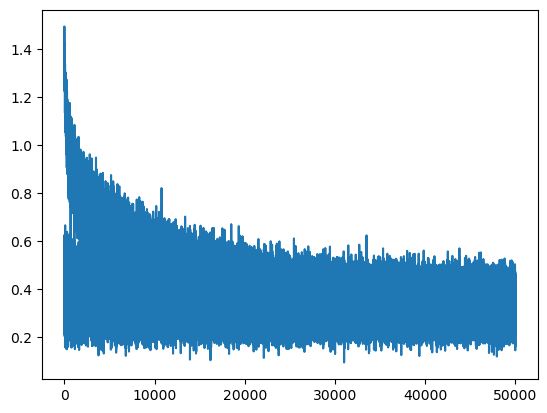

In [50]:
# ============================================================
# 训练循环：50000 步 mini-batch 梯度下降
# 每步：随机采样 -> 前向传播 -> 计算损失 -> 反向传播 -> 更新参数
# ============================================================
for i in range(50000):

    # --- mini-batch 采样 ---
    # mini-batch 大小 32 是平衡速度和梯度质量的常用选择
    num_minibatches=32

    ix=torch.randint(0, Xtr.shape[0], (num_minibatches,)) # 从训练集随机抽 32 个样本索引

    # --- 前向传播 (forward pass) ---
    emb=C[Xtr[ix]]                      # 查嵌入表：(32,3) -> (32,3,10)
    h=torch.tanh(emb.view(-1, 30) @ W1 + b1) # 隐藏层：(32,30) @ (30,200) -> tanh -> (32,200)
    logits=h @ W2 + b2                   # 输出层：(32,200) @ (200,27) -> (32,27)

    # 使用 F.cross_entropy 代替手动 softmax+NLL（数值更稳定，避免 exp 溢出）
    loss=F.cross_entropy(logits, Ytr[ix])

    # --- 反向传播 (backward pass) ---
    for p in parameters:
        p.grad=None                      # 清零梯度（比 .zero_() 更高效）
    loss.backward()                      # 自动计算所有参数的梯度

    # --- 参数更新 ---
    lr=0.01                              # 学习率（后续会通过 lr sweep 调优这个值）
    for p in parameters:
        p.data += -lr * p.grad           # 梯度下降：参数 -= 学习率 x 梯度

    # --- 记录训练统计 ---
    stepi.append(i)
    lossi.append(loss.log10().item())    # 记录 log10(loss) 方便观察数量级变化

# 打印最终 mini-batch loss 并绘制训练曲线
print(f'The minibatch loss is {loss.item()}')
plt.plot(stepi, lossi)

## 8. 模型评估 — 训练集 vs 验证集

**概念解释：** 训练完成后，我们分别在训练集和验证集上计算 loss。
如果验证集 loss 远大于训练集 loss，说明模型过拟合（overfitting）了。

**直觉理解：** 训练集 loss $\approx$ 2.17，验证集 loss $\approx$ 2.20——差距不大，
说明模型泛化能力还不错。完全随机猜测的理论 loss 是 $-\log(1/27) \approx 3.30$，
所以 2.17 已经远好于随机。

- **训练集 loss 低 + 验证集 loss 高** → 过拟合（模型"背答案"了）
- **训练集 loss 高 + 验证集 loss 高** → 欠拟合（模型能力不够）
- **两者都低且接近** → 理想状态

In [51]:
# ============================================================
# 评估训练集损失（不使用 mini-batch，用全部训练数据）
# ============================================================
emb=C[Xtr]                              # 全部训练数据查嵌入
h=torch.tanh(emb.view(-1, 30) @ W1 + b1) # 隐藏层前向传播
logits=h @ W2 + b2                       # 输出层
loss=F.cross_entropy(logits, Ytr)        # 在全部训练集上计算交叉熵
print(f'The train data set loss is {loss.item()}')

The train data set loss is 2.0867865085601807


In [52]:
# ============================================================
# 评估验证集损失（检测是否过拟合）
# ============================================================
emb=C[Xdev]                              # 全部验证数据查嵌入
h=torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits=h @ W2 + b2
loss=F.cross_entropy(logits, Ydev)       # 验证集交叉熵
print(f'The dev data set loss is {loss.item()}')

The dev data set loss is 2.1382675170898438


## 9. 从模型中采样生成名字

**概念解释：** 模型训练好后，我们可以用它来生成新名字。
过程是：从全零上下文 `...` 开始，模型预测下一个字符的概率分布，
根据概率随机采样一个字符，加入上下文，重复直到生成终止符 `.`。

**直觉理解：** 这就像让训练好的"输入法"自动打字：
输入法先根据 `...` 猜第一个字母（可能是 `j` 或 `b`），
然后根据已有的字母继续猜下一个，直到它觉得"这个名字该结束了"（生成 `.`）。
因为每一步是概率采样而非取最大值（argmax），所以每次生成的名字都不同——这赋予了模型**创造力**。

In [53]:
# ============================================================
# 从训练好的模型中采样生成 20 个新名字
# ============================================================
g=torch.Generator().manual_seed(2147483647) # 固定种子保证可复现
for _ in range(20):                      # 生成 20 个名字
    out=[]                               # 存储当前名字的字符
    context=[0]*block_size               # 初始上下文：'...'
    while True:
        emb=C[torch.tensor([context])]   # 查嵌入：(1,3) -> (1,3,10)
        h=torch.tanh(emb.view(-1, 30) @ W1 + b1) # 隐藏层

        logits=h @ W2 + b2              # 输出 logits

        probs=F.softmax(logits, dim=1)   # 转为概率分布

        ix=torch.multinomial(probs, num_samples=1, generator=g).item() # 按概率采样一个字符
        context=context[1:]+[ix]         # 更新上下文窗口
        out.append(ix)
        if ix==0:                        # 如果生成了终止符 '.'，结束当前名字
            break
    # print(context)
    print(''.join(itos[i] for i in out)) # 将索引序列转回字符串并打印

junide.
jayana.
julifay.
adiya.
jith.
tolian.
juel.
kalania.
zamilena.
jadeyaine.
immadse.
siely.
arteziavaun.
kyfoetum.
maryas.
walesani.
core.
yarion.
kashani.
werimii.


## 10. 可视化 — 嵌入空间与损失曲线

**概念解释：** 将 27 个字符的嵌入向量画在坐标系上，
可以直观地看到模型学到了哪些字符之间是"相似的"。

**直觉理解：** 如果模型学得好，功能相似的字符会在嵌入空间中靠得很近。
比如元音字母（a, e, i, o, u）可能聚在一起，因为它们在名字中的"角色"类似。
这就是嵌入层的魔力——它自动发现了字符之间的语义关系，而我们从未告诉它"哪些是元音"。

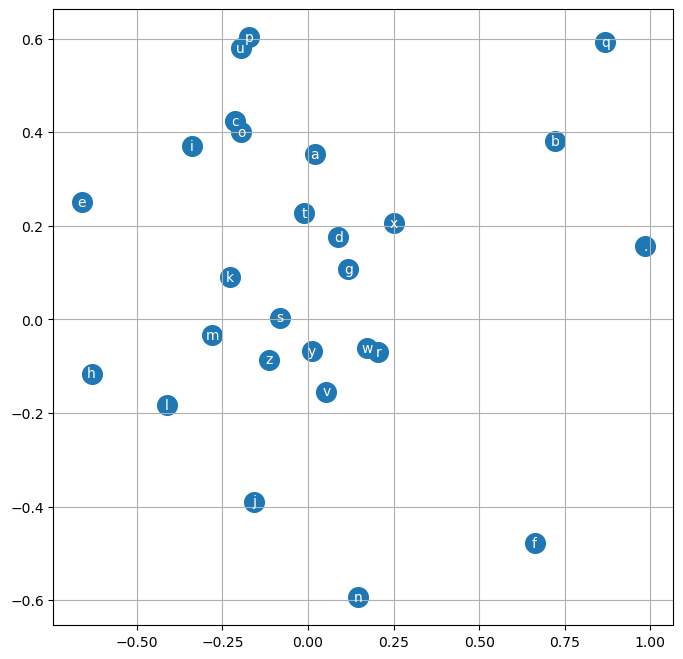

In [54]:
# ============================================================
# 可视化嵌入空间：每个字符在 2D 空间中的位置
# 相似字符（如元音）会自动聚集在一起
# ============================================================
plt.figure(figsize=(8,8))                # 设置画布大小
plt.scatter(C[:,0].data, C[:,1].data, s=200) # 绘制所有字符的 2D 嵌入坐标
for i in range(C.shape[0]):              # 在每个点上标注字符名称
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## 11. 学习率探索（Learning Rate Sweep）

**概念解释：** 学习率（Learning Rate）是决定每次参数更新步幅大小的超参数。
太大会导致训练不稳定（loss 震荡甚至发散），太小会导致训练太慢。

**直觉理解：** 学习率就像下山时的步幅。
- 步子太大 → 跨过最低点，在两边山坡来回跳（loss 震荡）
- 步子太小 → 一步一步挪，天黑了还没到山脚（训练太慢）
- 合适的步幅 → 又快又稳地走到谷底

**生活类比：** 蒙眼走下山——你感受脚下哪边更陡（梯度），然后往低处迈一步（学习率决定步幅）。
步子太大直接跨过山谷跳到对面山坡上来回震荡，步子太小天黑都走不到。

常见策略是**先大后小**：开始用较大学习率快速接近最优区域，然后减小学习率精细调整。

ValueError: x and y must have same first dimension, but have shapes (1000,) and (400000,)

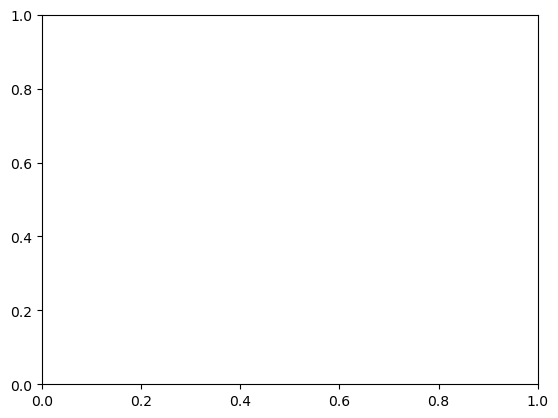

In [55]:
plt.plot(lrs,lossi)                      # 学习率（线性刻度）vs 每步 loss
plt.grid()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (400000,)

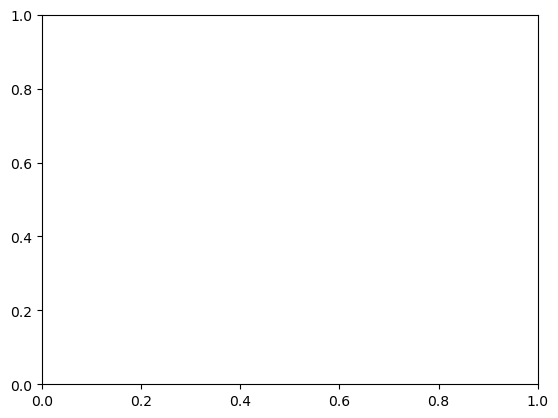

In [56]:
plt.plot(lre,lossi)                      # 学习率（对数刻度）vs loss -- 更容易看出最优区间
plt.grid()

### 手动学习率对比实验

下面对 8 个不同的学习率（0.001 到 0.5）分别从头训练 100 步，
绘制损失曲线来直观比较效果。可以看到：
- 学习率太小（0.001）：loss 几乎不动
- 学习率太大（0.5）：loss 震荡
- 中间值（0.05~0.2）：loss 稳步下降

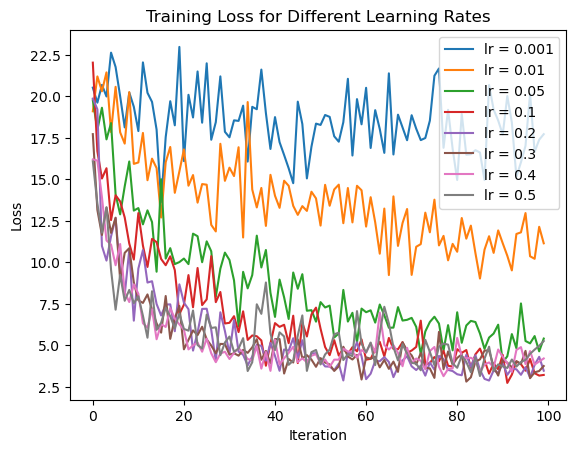

In [57]:
# ============================================================
# 学习率对比实验：对 8 个不同 lr 分别训练 100 步，比较损失曲线
# ============================================================
for lr in [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:

    # 每个 lr 都从相同的随机初始化开始（保证公平比较）
    g=torch.Generator().manual_seed(2147483647)
    C=torch.randn((27,2), generator=g)
    W1=torch.randn((6,100), generator=g)
    b1=torch.randn(100, generator=g)
    W2=torch.randn((100,27), generator=g)
    b2=torch.randn(27, generator=g)
    parameters=[C, W1, b1, W2, b2]


    for p in parameters:
        p.requires_grad=True

    lossi=[]                             # 记录当前 lr 的损失曲线

    for _ in range(100):                 # 每个 lr 训练 100 步

        # mini-batch 采样
        num_minibatches=32
        ix=torch.randint(0, X.shape[0], (num_minibatches,))

        # 前向传播
        emb=C[X[ix]]                     # (32,3) -> (32,3,2)
        h=torch.tanh(emb.view(-1, 6) @ W1 + b1)
        logits=h @ W2 + b2

        loss=F.cross_entropy(logits, Y[ix])

        lossi.append(loss.item())        # 记录 loss

        # 反向传播 + 更新
        for p in parameters:
            p.grad=None
        loss.backward()
        for p in parameters:
            p.data += -lr * p.grad

    # 每个 lr 画一条带标签的曲线
    plt.plot(lossi, label=f'lr = {lr}')
    plt.grid()

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss for Different Learning Rates')
plt.show()

In [58]:
# ============================================================
# 学习率扫描实验：在对数空间 10^(-3) ~ 10^0 均匀取 100 个 lr
# 每个 lr 训练 100 步，记录最终 loss，绘制 lr-loss 曲线
# ============================================================
lossi=[]
data_lr=torch.linspace(-3, 0, 100)       # 对数空间：-3 到 0
data_lrs=10**data_lr                     # 实际学习率：0.001 到 1.0
for lr in data_lrs:                      # 遍历每个候选学习率

    # 每次从同一初始化开始
    g=torch.Generator().manual_seed(2147483647)
    C=torch.randn((27,2), generator=g)
    W1=torch.randn((6,100), generator=g)
    b1=torch.randn(100, generator=g)
    W2=torch.randn((100,27), generator=g)
    b2=torch.randn(27, generator=g)
    parameters=[C, W1, b1, W2, b2]

    for p in parameters:
        p.requires_grad=True

    for _ in range(100):                 # 每个 lr 训练 100 步

        num_minibatches=32
        ix=torch.randint(0, X.shape[0], (num_minibatches,))

        emb=C[X[ix]]
        h=torch.tanh(emb.view(-1, 6) @ W1 + b1)
        logits=h @ W2 + b2

        loss=F.cross_entropy(logits, Y[ix])

        for p in parameters:
            p.grad=None
        loss.backward()
        for p in parameters:
            p.data += -lr * p.grad

    lossi.append(loss.item())            # 记录每个 lr 训练后的最终 loss

C:\Users\Smiling\AppData\Local\Temp\ipykernel_19732\2483094450.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


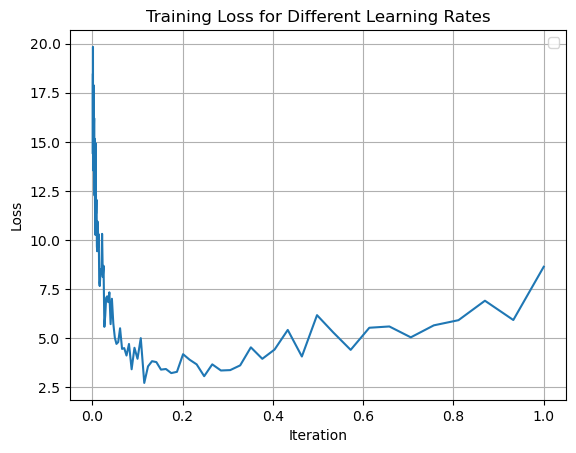

In [59]:
# 绘制学习率扫描结果：lr（线性刻度）vs 最终 loss
plt.plot(data_lrs,lossi)
plt.grid()
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss for Different Learning Rates')
plt.show()

C:\Users\Smiling\AppData\Local\Temp\ipykernel_19732\2141780027.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


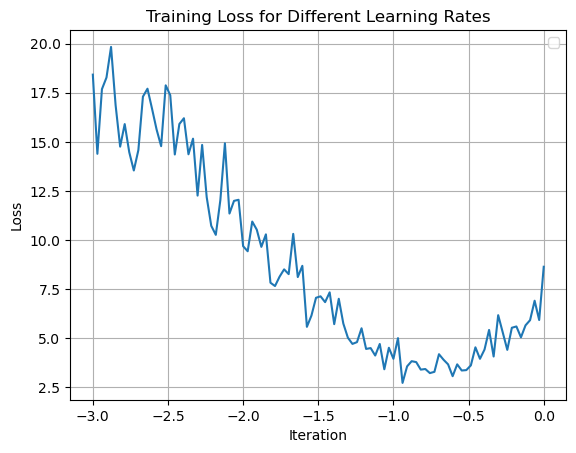

In [60]:
# 绘制学习率扫描结果：lr（对数刻度）vs 最终 loss -- 更容易看出最优区间
plt.plot(data_lr,lossi)                  # x 轴用对数值
plt.grid()
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss for Different Learning Rates')
plt.show()

In [61]:
min(lossi)                               # 所有学习率中最低的 loss 值

2.706393241882324

---

## 附录：Tensor 底层原理 — `view` 与 `storage`

**概念解释：** PyTorch 的 `view` 操作不会复制数据，只是改变你"看"数据的方式。
底层数据始终存储在一块连续的内存（`storage`）中，`view` 只是改变了步长（stride）和形状（shape）。

**直觉理解：** 想象一排 18 个人站成一条线。
`view(6,3)` 就是让他们重新排成 6 行 3 列的方阵——人还是那些人，位置没变，
只是你换了一种方式来看他们。这就是为什么 `view` 几乎是零成本的——它不移动任何数据。

- `a.storage()` 查看底层内存中的原始数据
- `a.view(6,3)` 不复制数据，只改变"观察方式"
- 这也是为什么 `emb.view(-1, 6)` 能高效地将 $(N, 3, 2)$ 变成 $(N, 6)$

In [62]:
a=torch.arange(18)                      # 创建一个包含 0~17 的一维张量
a.shape                                  # shape=(18,)，一维

torch.Size([18])

In [63]:
a.view(6,3)                              # 零成本变形：(18,) -> (6,3)，不复制数据，只改"观察方式"

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])

In [64]:
a.storage()                              # 查看底层 storage：数据始终是 0~17 的一维连续内存

C:\Users\Smiling\AppData\Local\Temp\ipykernel_19732\4016106191.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()                              # 查看底层 storage：数据始终是 0~17 的一维连续内存


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

### 嵌入拼接的三种等价方式

将 $(N, 3, 2)$ 的嵌入张量拼接成 $(N, 6)$ 有三种方法：
1. `emb.view(-1, 6)` — 最高效（零拷贝），本 notebook 实际使用的方法
2. `torch.cat(torch.unbind(emb, 1), 1)` — 先拆后拼
3. `torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1)` — 手动切片

三者结果完全相同，但 `view` 不创建新内存，性能最优。

In [65]:
# 方法 1：torch.cat + unbind（先按 dim=1 拆开，再沿 dim=1 拼接）
torch.cat(torch.unbind(emb, dim=1), dim=1)

tensor([[ 2.5056, -4.7215,  2.5056, -4.7215, -1.2286,  0.6259],
        [ 2.5056, -4.7215, -1.6129, -0.2145,  2.4878,  0.3892],
        [-1.6129, -0.2145, -0.2902,  1.0363,  1.2995, -0.4096],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.4878,  0.3892, -0.2902,  1.0363],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [-1.3116, -1.0336,  1.2995, -0.4096, -0.5295, -0.7200],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  0.4567,  0.5280],
        [-0.2902,  1.0363,  1.2995, -0.4096, -1.3116, -1.0336],
        [ 2.5056, -4.7215,  2.4878,  0.3892, -0.2902,  1.0363],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 1.2995, -0.4096, -0.2902,  1.0363,  0.7452,  0.6597],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.1301,  0.6298],
        [ 2.5056, -4.7215,  2.5056, -4.7

In [66]:
# 方法 2：手动切片拼接（最直观但创建中间张量，效率较低）
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1)

tensor([[ 2.5056, -4.7215,  2.5056, -4.7215, -1.2286,  0.6259],
        [ 2.5056, -4.7215, -1.6129, -0.2145,  2.4878,  0.3892],
        [-1.6129, -0.2145, -0.2902,  1.0363,  1.2995, -0.4096],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.4878,  0.3892, -0.2902,  1.0363],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [-1.3116, -1.0336,  1.2995, -0.4096, -0.5295, -0.7200],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  0.4567,  0.5280],
        [-0.2902,  1.0363,  1.2995, -0.4096, -1.3116, -1.0336],
        [ 2.5056, -4.7215,  2.4878,  0.3892, -0.2902,  1.0363],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 1.2995, -0.4096, -0.2902,  1.0363,  0.7452,  0.6597],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.5056, -4.7215],
        [ 2.5056, -4.7215,  2.5056, -4.7215,  2.1301,  0.6298],
        [ 2.5056, -4.7215,  2.5056, -4.7

In [67]:
X.shape, emb.shape                      # X: (32,3) 索引矩阵，emb: (32,3,2) 嵌入结果

(torch.Size([228146, 3]), torch.Size([32, 3, 2]))

### 嵌入查表的底层机制

下面展示 `C[X]` 到底做了什么：对于 $X$ 中的每个整数索引，
PyTorch 去 $C$ 矩阵中取对应的那一行。这就是"嵌入查表"的全部秘密。

- `C[5]` → 取第 5 行（字符 'e' 的嵌入向量）
- `C[[5,13,13]]` → 同时取第 5、13、13 行
- `C[X]` → 对 $X$ 中每个元素都做查表，整个 $(N,3)$ 矩阵变成 $(N,3,2)$ 张量

In [68]:
C[5]                                     # 查看字符 'e'(索引5) 的 2 维嵌入向量

tensor([-1.7013, -0.0133], grad_fn=<SelectBackward0>)

In [69]:
C[[5, 13, 13]]                           # 批量查表：同时查索引 5, 13, 13 的嵌入向量

tensor([[-1.7013, -0.0133],
        [ 2.6748,  0.5050],
        [ 2.6748,  0.5050]], grad_fn=<IndexBackward0>)

In [70]:
X[3]                                     # 第 4 个样本的上下文：字符索引 [5, 13, 13]

tensor([ 5, 13, 13])

In [71]:
C[X[3]]                                  # C[X[3]] 等价于 C[[5,13,13]]，结果完全一样

tensor([[-1.7013, -0.0133],
        [ 2.6748,  0.5050],
        [ 2.6748,  0.5050]], grad_fn=<IndexBackward0>)

In [72]:
# C[X] 对整个 X 矩阵做查表：X 中每个索引都被替换为对应的嵌入向量
# (32, 3) 的索引矩阵 -> (32, 3, 2) 的嵌入矩阵
C[X]

tensor([[[ 2.7439, -4.4727],
         [ 2.7439, -4.4727],
         [ 2.7439, -4.4727]],

        [[ 2.7439, -4.4727],
         [ 2.7439, -4.4727],
         [-1.7013, -0.0133]],

        [[ 2.7439, -4.4727],
         [-1.7013, -0.0133],
         [ 2.6748,  0.5050]],

        ...,

        [[-0.3838, -0.0569],
         [-0.3838, -0.0569],
         [-0.2212, -0.9161]],

        [[-0.3838, -0.0569],
         [-0.2212, -0.9161],
         [-0.3838, -0.0569]],

        [[-0.2212, -0.9161],
         [-0.3838, -0.0569],
         [ 0.2914, -0.1133]]], grad_fn=<IndexBackward0>)

In [73]:
# One-hot 编码 + 矩阵乘法 = 嵌入查表（但速度慢得多！）
# 这行代码证明了 C[5] 和 one_hot(5) @ C 是等价的
F.one_hot(torch.tensor([5]), num_classes=27).float() @ C

tensor([[-1.7013, -0.0133]], grad_fn=<MmBackward0>)